Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Training samples: 1904
Testing samples: 476
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000135 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1557
[LightGBM] [Info] Number of data points in the train set: 1904, number of used features: 7
[LightGBM] [Info] Start training from score -5.472271
[LightGBM] [Info] Start training from score -3.169686
[LightGBM] [Info] Start training from score -5.472271
[LightGBM] [Info] Start training from score -3.169686
[LightGBM] [Info] Start training from score -5.472271
[LightGBM] [Info] Start training from score -3.169686
[LightGBM] [Info] Start training from score -5.472271
[LightGBM] [Info] Start training from score -3.169686
[LightGBM] [Info] Start training from score -5.472271
[LightGBM] [Info] Start training from score -5.472271

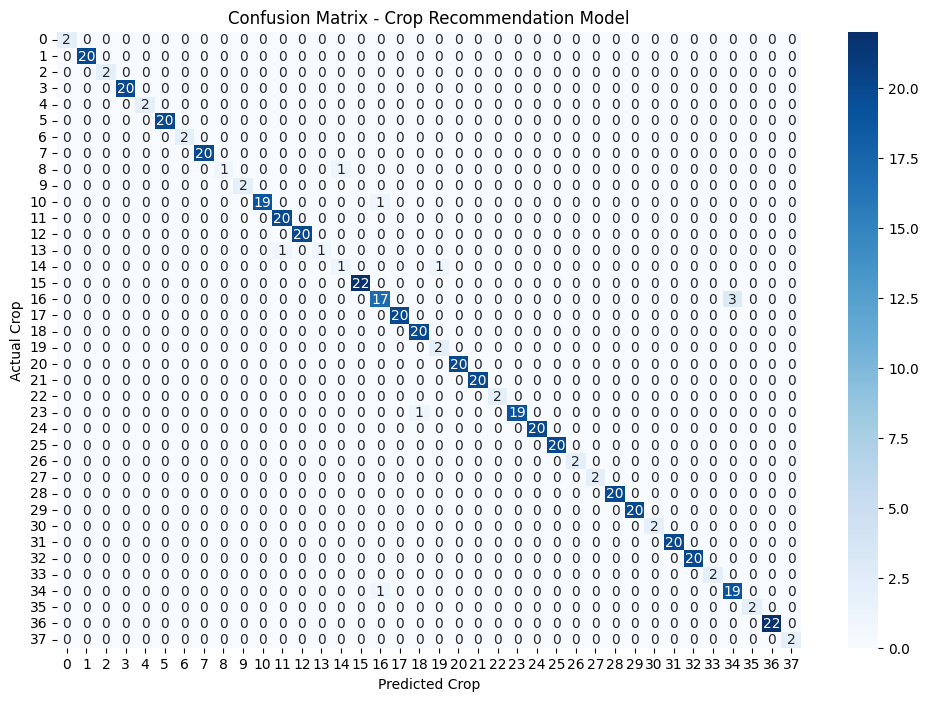


Model saved successfully!


In [ ]:
# 📍 Install LightGBM
!pip install lightgbm

# 📍 Import libraries
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 📍 Mount Google Drive (if dataset is there)
from google.colab import drive
drive.mount('/content/drive')

# 📍 Load dataset
df = pd.read_csv('/content/drive/MyDrive/FarmWise/crop_recommendation.csv')

# 📍 Prepare features and target
X = df.drop('label', axis=1)
y = df['label']

# 📍 Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

# 📍 Train LightGBM model
model = lgb.LGBMClassifier()
model.fit(X_train, y_train)

print("\nModel training completed!")

# 📍 Make predictions
y_pred = model.predict(X_test)

# 📍 Evaluate the model
print("\nAccuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 📍 Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Crop Recommendation Model')
plt.xlabel('Predicted Crop')
plt.ylabel('Actual Crop')
plt.show()

# 📍 Save the trained model
joblib.dump(model, '/content/drive/MyDrive/FarmWise/crop_recommendation_model.pkl')

print("\nModel saved successfully!")


In [ ]:
def predict_crop(temp, humidity, ph):
    sample = pd.DataFrame({
        'N': [90], 'P': [40], 'K': [50],  # Neutral values
        'temperature': [temp],
        'humidity': [humidity],
        'ph': [ph],
        'rainfall': [500]
    })
    prediction = model.predict(sample)
    return prediction[0]

# Example usage
result = predict_crop(25.2, 64, 6.3)
print("Predicted Crop:", result)


Predicted Crop: watermelon
